In [1]:
#套件
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
from pydicom import dcmread
import os
import cv2
import keras
from keras.layers import Dense, Dropout, Flatten
from keras.models import Sequential 
from keras.layers import Convolution2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D, AveragePooling2D
import matplotlib.pyplot as plt
from keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from keras.layers import concatenate
from keras import optimizers
from sklearn.model_selection import GridSearchCV
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from tensorflow.keras.applications import ResNet50
import gc
from tensorflow.keras import regularizers
from keras import callbacks
from keras import backend as K
from sklearn.model_selection import KFold
import glob
import pickle

from keras.layers import Dense, Input, Conv2D, Flatten, MaxPooling2D, Activation, Dropout, Average
from keras.models import Model
from keras.models import load_model
from keras.metrics import categorical_crossentropy
from tensorflow.keras.layers import Dense, BatchNormalization


In [2]:
import numpy as np
import os
import glob
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import keras
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, Flatten, MaxPooling2D, Activation, Dropout, Average
from keras.models import Model
from keras.models import load_model
from keras.metrics import categorical_crossentropy
from keras.callbacks import ModelCheckpoint
from keras import callbacks
from keras import backend as K
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from keras.preprocessing.image import ImageDataGenerator
import gc

In [3]:
df = pd.read_csv('train_hwk01_new.csv')
df

,ID,Age,Gender,FilePath,index,Stage_New
0,A175204,69,0,/DICOM/A175204/00010018,7,2
1,A122221,56,0,/DICOM/A122221/00010034,15,1
2,A54671,82,0,/DICOM/A54671/00010021,8,1
3,A31117,71,1,/DICOM/A31117/00010022,10,2
4,A653195,68,0,/DICOM/A653195/00010016,7,2
...,...,...,...,...,...,...
156,A717094,80,1,/DICOM/A717094/00010022,11,4
157,A741758,54,1,/DICOM/A741758/00010017,9,5
158,A646753,75,1,/DICOM/A646753/00010023,12,4
159,A679904,62,1,/DICOM/A679904/00010020,9,4


In [4]:
df['Stage_New'].value_counts() #imbalanced data

4    69
3    42
2    23
1    17
5     6
0     4
Name: Stage_New, dtype: int64

In [5]:
#load training data

from tensorflow.keras.utils import to_categorical 
y_train = df['Stage_New']

y_train = list(y_train)


y_train_all = to_categorical(y_train)

In [6]:
#rewrite file path
x = [i for i in df['FilePath']] 

for i in range(len(x)):
    x[i] = x[i].replace('/','\\')
    
#create new filename and new path
file_name = []
for i in range(len(x)):
    s = x[i]
    s = s.split('\\') #split strings
    file_name.append(s[-1]) #list append filename
    s.pop()
    x[i] = '\\'.join(map(str,s)) # new filepath
    
# adding new cols to df
df['filepath'] = x
df['file_name'] = file_name

# 記住目前目錄
x = os.getcwd()
x

'C:\\Users\\James'

In [7]:
df

,ID,Age,Gender,FilePath,index,Stage_New,filepath,file_name
0,A175204,69,0,/DICOM/A175204/00010018,7,2,\DICOM\A175204,00010018
1,A122221,56,0,/DICOM/A122221/00010034,15,1,\DICOM\A122221,00010034
2,A54671,82,0,/DICOM/A54671/00010021,8,1,\DICOM\A54671,00010021
3,A31117,71,1,/DICOM/A31117/00010022,10,2,\DICOM\A31117,00010022
4,A653195,68,0,/DICOM/A653195/00010016,7,2,\DICOM\A653195,00010016
...,...,...,...,...,...,...,...,...
156,A717094,80,1,/DICOM/A717094/00010022,11,4,\DICOM\A717094,00010022
157,A741758,54,1,/DICOM/A741758/00010017,9,5,\DICOM\A741758,00010017
158,A646753,75,1,/DICOM/A646753/00010023,12,4,\DICOM\A646753,00010023
159,A679904,62,1,/DICOM/A679904/00010020,9,4,\DICOM\A679904,00010020


In [8]:
X_train_all = []

for i in range(len(df)):
    filepath = x + df['filepath'][i] #設定path = 當前目錄 + filepath
    os.chdir(filepath) #到指定資料夾
    ds = dcmread(df['file_name'][i]) #read dicom
    arr = ds.pixel_array # read image
    arr = arr[(df['index'][i])-1] #根據train.csv提供index選圖片，python從0開始，csv_index從1開始，故減1
    arr = arr[39:89,39:89] #crop image ，將圖片切成50*50 去掉無用黑背景
    arr = np.array(arr)
    image = np.expand_dims(arr,axis=2) #增加成3channels
    image = np.concatenate((image,image,image),axis=-1)
    image = image / 255  #歸一化
    X_train_all.append(image)

X_train_all = np.array(X_train_all)
X_train_all.shape

(161, 50, 50, 3)

In [9]:
X2_train = np.array(df[['Age','Gender']])

In [10]:
X2_train.shape

(161, 2)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_valid, X2_train, X2_valid, y_train, y_valid = train_test_split(X_train_all,
                                    X2_train, y_train_all, random_state=77, train_size=0.75)

In [12]:
batch_size = 10
# Define the image transformations here
gen = ImageDataGenerator(rotation_range=15, 
                        width_shift_range=0.2,
                        height_shift_range=0.2,
                        shear_range=0.2,
                        zoom_range=0.2,
                        horizontal_flip=True, 
                        fill_mode='nearest')

# Here is the function that merges our two generators
# We use the exact same generator with the same random seed for both the y and angle arrays
def gen_flow_for_two_inputs(X1, X2, y):
    genX1 = gen.flow(X1,y,  batch_size=batch_size,seed=666)
    genX2 = gen.flow(X1,X2, batch_size=batch_size,seed=666)
    while True:
            X1i = genX1.next()
            X2i = genX2.next()
            #Assert arrays are equal - this was for peace of mind, but slows down training
            #np.testing.assert_array_equal(X1i[0],X2i[0])
            yield [X1i[0], X2i[1]], X1i[1]

# Finally create generator
gen_flow = gen_flow_for_two_inputs(X_train, X2_train, y_train)

In [29]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=1e-4, decay=0.0) #優化採用adam ，起始直因batch size小。取小一點。

In [30]:
from keras.callbacks import EarlyStopping


callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=15,
    verbose=0,
    mode="min")
    



In [31]:
import tensorflow as tf
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

In [32]:
from tensorflow.keras.callbacks import LearningRateScheduler
callback2 = LearningRateScheduler(scheduler)

In [33]:
def mlp():
    model = Sequential() #採keras sequential model
    model.add(Dense(256, activation='relu', input_dim=2)) #input layer，input dim == 2 (age,gender)，output 
    model.add(Dense(64, activation='relu')) # hidden layer，outputs
    return model


In [34]:
mlp = mlp()

In [35]:
mlp.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_7 (Dense)              (None, 256)               768       
_________________________________________________________________
dense_8 (Dense)              (None, 64)                16448     
Total params: 17,216
Trainable params: 17,216
Non-trainable params: 0
_________________________________________________________________


In [36]:
def res():
    input_shape = (50, 50, 3)
    resMod = ResNet50(include_top=False, weights='imagenet',input_shape=input_shape) #not include top
    x = resMod.layers[-1].output
    x = BatchNormalization()(x)
    x = Flatten()(x)
    x = Dense(32, activation="relu")(x)
    model = Model(inputs=resMod.input, outputs=x) #create new model
    for layer in resMod.layers:
        layer.trainable = True
    return model

In [37]:
model= res()

In [38]:
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 50, 50, 3)]  0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 56, 56, 3)    0           input_3[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 25, 25, 64)   9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
conv1_bn (BatchNormalization)   (None, 25, 25, 64)   256         conv1_conv[0][0]                 
____________________________________________________________________________________________

In [39]:
combinedInput = concatenate([model.output, mlp.output]) #concatenate net.mlp2 output as new input
x = Dense(512, activation="relu", kernel_regularizer=regularizers.L2(0.01))(combinedInput)
x = Dense(64, activation="relu", kernel_regularizer=regularizers.L2(0.01))(x)
x = BatchNormalization(name = 'bn_fc01')(x)
x = Dense(6, activation="softmax")(x)# 設定新模型的架構
model2 = Model(inputs=[model.input, mlp.input], outputs=x) # new model architecture

model2.compile(loss='categorical_crossentropy',optimizer=optimizer, metrics=['accuracy']) 
model2.summary() #完整 model summary

Model: "model_4"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 50, 50, 3)]  0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 56, 56, 3)    0           input_3[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 25, 25, 64)   9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
conv1_bn (BatchNormalization)   (None, 25, 25, 64)   256         conv1_conv[0][0]                 
____________________________________________________________________________________________

In [40]:
# train the model
print("training")
#fitting model
history = model2.fit(
    gen_flow,
    validation_data = ([X_valid, X2_valid], y_valid),
    steps_per_epoch=len(X_train) / batch_size, epochs=1000, callbacks=[callback,callback2], verbose=2)

print("finished...")


training
Epoch 1/1000
12/12 - 8s - loss: 4.7405 - accuracy: 0.2417 - val_loss: 5.1162 - val_accuracy: 0.0976
Epoch 2/1000
12/12 - 1s - loss: 4.5868 - accuracy: 0.2250 - val_loss: 4.7563 - val_accuracy: 0.2439
Epoch 3/1000
12/12 - 1s - loss: 4.5196 - accuracy: 0.2667 - val_loss: 4.4698 - val_accuracy: 0.2439
Epoch 4/1000
12/12 - 1s - loss: 4.2215 - accuracy: 0.3833 - val_loss: 4.3063 - val_accuracy: 0.2439
Epoch 5/1000
12/12 - 1s - loss: 4.2146 - accuracy: 0.4000 - val_loss: 4.1193 - val_accuracy: 0.2439
Epoch 6/1000
12/12 - 1s - loss: 4.0212 - accuracy: 0.4417 - val_loss: 4.0114 - val_accuracy: 0.2439
Epoch 7/1000
12/12 - 1s - loss: 3.9635 - accuracy: 0.4667 - val_loss: 3.7880 - val_accuracy: 0.4146
Epoch 8/1000
12/12 - 1s - loss: 3.8211 - accuracy: 0.5083 - val_loss: 3.8007 - val_accuracy: 0.2439
Epoch 9/1000
12/12 - 1s - loss: 3.8269 - accuracy: 0.4667 - val_loss: 3.7840 - val_accuracy: 0.4634
Epoch 10/1000
12/12 - 1s - loss: 3.8784 - accuracy: 0.4667 - val_loss: 3.7595 - val_accurac

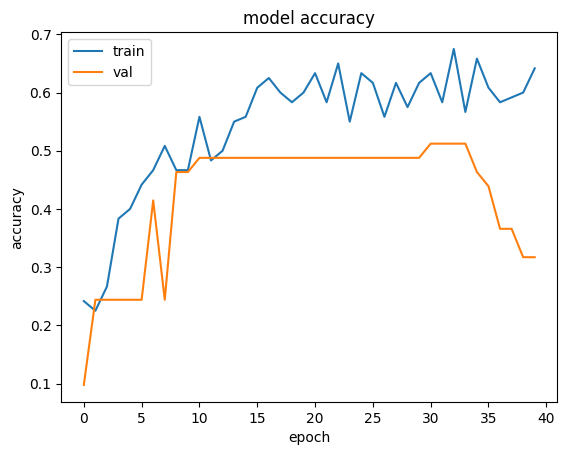

In [41]:
# accuracy curve
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

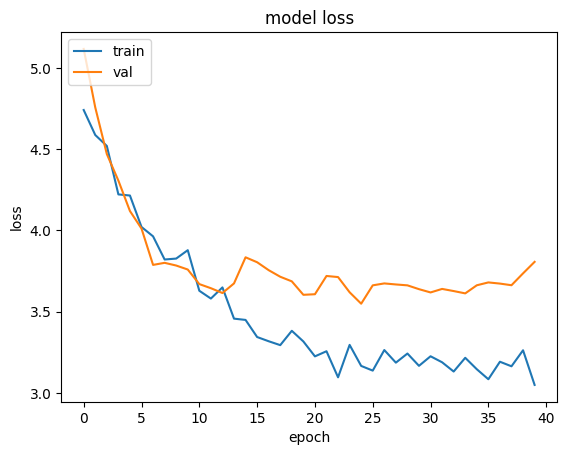

In [42]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [43]:
os.chdir('C:\\Users\\James')#reset filepath


# testing data
df2 = pd.read_csv('test.csv')
df2


#loading testing image
x = [i for i in df2['FilePath']] 
#rewrite file path
for i in range(len(x)):
    x[i] = x[i].replace('/','\\')
#create filename and path
file_name = []
for i in range(len(x)):
    s = x[i]
    s = s.split('\\')
    file_name.append(s[-1])
    s.pop()
    x[i] = '\\'.join(map(str,s))
# adding to df
df2['filepath'] = x
df2['file_name'] = file_name

data2 = []
for i in range(len(df2)):
    filepath = 'C:\\Users\\James' + df2['filepath'][i] #設定path
    os.chdir(filepath) #到指定資料夾
    ds = dcmread(df2['file_name'][i]) #read dicom
    arr = ds.pixel_array # read image
    arr = arr[(df2['index'][i])-1] #根據index選圖片
    arr = arr[39:89,39:89] #轉成50*50 去掉無用黑背景
    arr = np.array(arr)
    image = np.expand_dims(arr,axis=2)
    image = np.concatenate((image,image,image),axis=-1)
    image = image / 255  #歸一化
    data2.append(image)

X1_test = np.array(data2) #change to np



















In [44]:
X1_test.shape

(41, 50, 50, 3)

In [45]:
# preparing second testing input(gender and age)
X2_test = df2[['Age','Gender']]
X2_test = np.array(X2_test)

In [46]:
preds2 = model2.predict([X1_test, X2_test]) # predicting labels for testing data


In [47]:
preds2 = np.around(preds2, decimals=2) #四捨五入到小數點第二位
preds2

array([[0.11, 0.03, 0.25, 0.12, 0.33, 0.17],
       [0.04, 0.02, 0.1 , 0.03, 0.75, 0.06],
       [0.19, 0.05, 0.57, 0.12, 0.02, 0.05],
       [0.22, 0.06, 0.38, 0.07, 0.07, 0.2 ],
       [0.08, 0.03, 0.43, 0.24, 0.11, 0.1 ],
       [0.46, 0.09, 0.29, 0.07, 0.03, 0.07],
       [0.11, 0.03, 0.39, 0.21, 0.17, 0.09],
       [0.06, 0.02, 0.24, 0.11, 0.46, 0.11],
       [0.03, 0.03, 0.16, 0.17, 0.5 , 0.1 ],
       [0.42, 0.06, 0.14, 0.08, 0.01, 0.28],
       [0.06, 0.03, 0.31, 0.15, 0.33, 0.12],
       [0.06, 0.02, 0.21, 0.12, 0.5 , 0.1 ],
       [0.05, 0.03, 0.24, 0.27, 0.33, 0.08],
       [0.11, 0.03, 0.17, 0.05, 0.3 , 0.34],
       [0.17, 0.06, 0.19, 0.09, 0.31, 0.18],
       [0.06, 0.03, 0.4 , 0.16, 0.22, 0.13],
       [0.09, 0.02, 0.15, 0.04, 0.61, 0.09],
       [0.02, 0.02, 0.09, 0.03, 0.78, 0.06],
       [0.05, 0.04, 0.45, 0.17, 0.18, 0.11],
       [0.14, 0.04, 0.17, 0.06, 0.47, 0.12],
       [0.08, 0.04, 0.26, 0.15, 0.25, 0.23],
       [0.32, 0.06, 0.22, 0.11, 0.02, 0.28],
       [0.

In [48]:
#create df
result_net = pd.DataFrame(preds2, columns = ['0','1','2','3','4','5'])
result_net

,0,1,2,3,4,5
0,0.11,0.03,0.25,0.12,0.33,0.17
1,0.04,0.02,0.10,0.03,0.75,0.06
2,0.19,0.05,0.57,0.12,0.02,0.05
3,0.22,0.06,0.38,0.07,0.07,0.20
4,0.08,0.03,0.43,0.24,0.11,0.10
5,0.46,0.09,0.29,0.07,0.03,0.07
6,0.11,0.03,0.39,0.21,0.17,0.09
7,0.06,0.02,0.24,0.11,0.46,0.11
8,0.03,0.03,0.16,0.17,0.50,0.10
9,0.42,0.06,0.14,0.08,0.01,0.28


In [49]:
maxValueIndex = result_net.idxmax(axis=1)
result_net['Stage'] = maxValueIndex #get Max_value index

In [50]:
result_net

,0,1,2,3,4,5,Stage
0,0.11,0.03,0.25,0.12,0.33,0.17,4
1,0.04,0.02,0.10,0.03,0.75,0.06,4
2,0.19,0.05,0.57,0.12,0.02,0.05,2
3,0.22,0.06,0.38,0.07,0.07,0.20,2
4,0.08,0.03,0.43,0.24,0.11,0.10,2
5,0.46,0.09,0.29,0.07,0.03,0.07,0
6,0.11,0.03,0.39,0.21,0.17,0.09,2
7,0.06,0.02,0.24,0.11,0.46,0.11,4
8,0.03,0.03,0.16,0.17,0.50,0.10,4
9,0.42,0.06,0.14,0.08,0.01,0.28,0


In [51]:
#output csv
from pathlib import Path  
filepath = Path('C:\\Users\\James\\ResNet50_6c.csv')  
filepath.parent.mkdir(parents=True, exist_ok=True)  
result_net.to_csv(filepath)